# Healthy Foods Classifier — XGBoost

 > Structure: data validation → training (cross-validation) → analysis → experiments.

This notebook trains an **XGBoost** multiclass classifier to predict `health_label` (Healthy / Moderate / Unhealthy) from engineered nutrient features in `foods_engineered_300.csv`.

Metrics reported (via stratified cross-validation): accuracy, macro precision/recall/F1, and AUROC (OvR macro) plus a confusion matrix.

In [1]:
# If you see missing-package errors, run once:
# !pip -q install xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
 )

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

## 1) Data Validation

This section checks schema, missing values, label distribution, and provides a quick look at feature distributions/correlations.

Loaded: foods_engineered_300.csv
Shape: (300, 18)


,description,protein_g,fat_g,carbs_g,energy_kcal,sugars_g,fiber_g,sodium_mg,potassium_mg,cholesterol_mg,protein_ratio,fat_ratio,carb_ratio,sugar_ratio,fiber_density,sodium_density,processed_level,health_label
0,"FRESH JICAMA STICKS WITH SRIRACHA SEASONING, S...",0.88,0.00,9.73,40.0,1.77,5.3,283.0,124.0,0.0,0.022000,0.000000,0.243250,0.181912,0.544707,7.075000,2,Unhealthy
1,"CAPPUCCINO DRINK MIX, PUMPKIN SPICE",0.00,30.00,60.00,533.0,33.33,0.0,1067.0,0.0,0.0,0.000000,0.056285,0.112570,0.555500,0.000000,2.001876,2,Unhealthy
2,GOURMET CARAMEL CORN,3.57,5.36,89.29,400.0,50.00,7.1,293.0,0.0,0.0,0.008925,0.013400,0.223225,0.559973,0.079516,0.732500,2,Moderate
3,"SALMON, SHRIMP & SCALLOPS",7.00,5.00,15.00,130.0,1.00,1.0,470.0,45.0,30.0,0.053846,0.038462,0.115385,0.066667,0.066667,3.615385,2,Unhealthy
4,"BUTTER COOKIES, BUTTER",5.88,17.65,67.65,441.0,29.41,2.9,235.0,206.0,59.0,0.013333,0.040023,0.153401,0.434738,0.042868,0.532880,2,Moderate


Label distribution:


health_label
Unhealthy    100
Moderate     100
Healthy      100
Name: count, dtype: int64

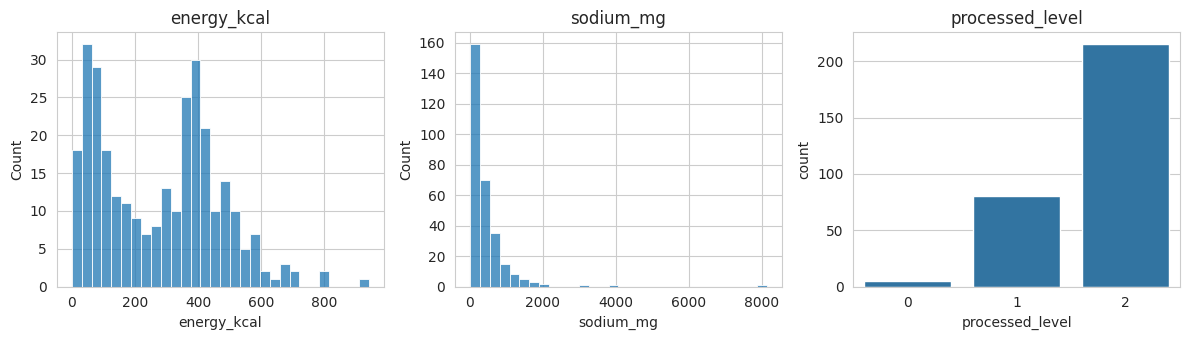

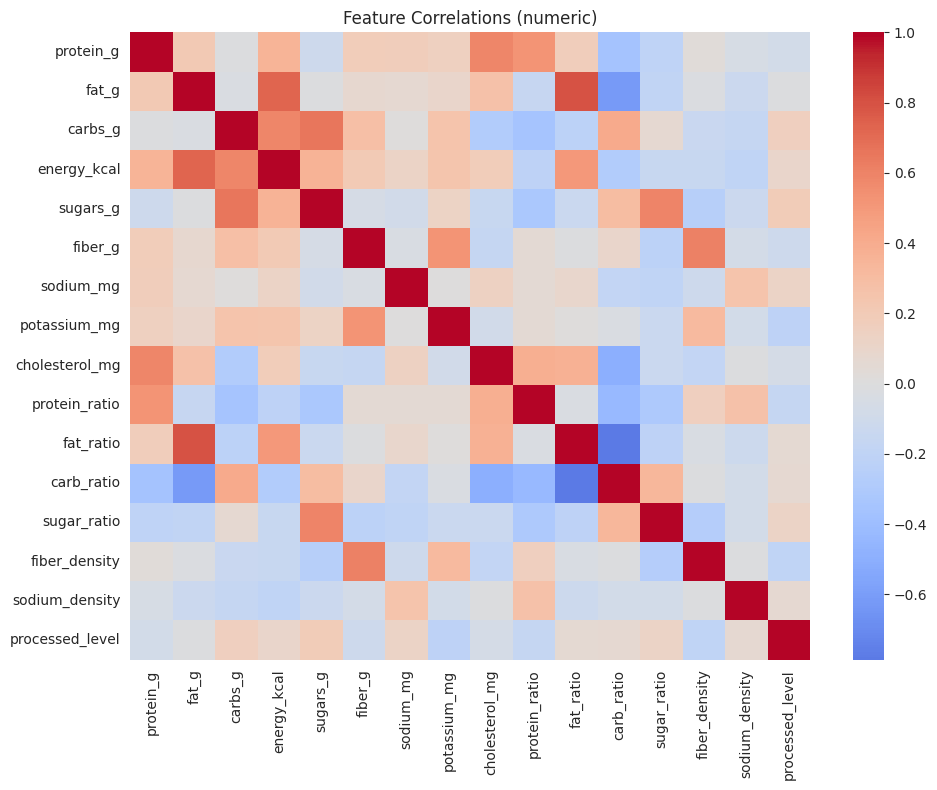

In [2]:
DATA_PATH = 'foods_engineered_300.csv'
if not os.path.exists(DATA_PATH):
    # Fallback for older repo layouts
    DATA_PATH = os.path.join('dataset_preprocessing', 'foods_engineered_300.csv')

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df.shape)
display(df.head(5))

required_cols = [
    'description',
    'protein_g','fat_g','carbs_g','energy_kcal','sugars_g','fiber_g','sodium_mg','potassium_mg','cholesterol_mg',
    'protein_ratio','fat_ratio','carb_ratio','sugar_ratio','fiber_density','sodium_density',
    'processed_level',
    'health_label',
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f'Missing columns: {missing}'

# Missing values check
na_total = int(df.isna().sum().sum())
assert na_total == 0, f'Found {na_total} NaNs (expected 0 for engineered CSV)'

print('Label distribution:')
display(df['health_label'].value_counts(dropna=False))

# Quick EDA
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
sns.histplot(df['energy_kcal'], bins=30, ax=axes[0]); axes[0].set_title('energy_kcal')
sns.histplot(df['sodium_mg'], bins=30, ax=axes[1]); axes[1].set_title('sodium_mg')
sns.countplot(x='processed_level', data=df, ax=axes[2]); axes[2].set_title('processed_level')
plt.tight_layout(); plt.show()

num_cols = [c for c in df.columns if c not in ('description','health_label')]
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlations (numeric)')
plt.tight_layout(); plt.show()

## 2) Training Setup (Features + Label Encoding)

We drop text fields from X and train on numeric engineered nutrition features. The target is `health_label` (3-class).

In [3]:
feature_cols = [
    'protein_g','fat_g','carbs_g','energy_kcal','sugars_g','fiber_g','sodium_mg','potassium_mg','cholesterol_mg',
    'protein_ratio','fat_ratio','carb_ratio','sugar_ratio','fiber_density','sodium_density',
    'processed_level',
]

X = df[feature_cols].astype(float).to_numpy()
y_str = df['health_label'].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)
class_names = list(le.classes_)
num_classes = len(class_names)

print('Classes:', class_names)
print('X shape:', X.shape, 'y shape:', y.shape)

Classes: ['Healthy', 'Moderate', 'Unhealthy']
X shape: (300, 16) y shape: (300,)


## 3) Model Training + Cross-Validation Evaluation

We use **StratifiedKFold** cross-validation to report robust metrics on this small dataset.

Reported per-fold and aggregated: accuracy, macro precision/recall/F1, AUROC (one-vs-rest macro) and a confusion matrix summed over folds.

Fold 1: {'accuracy': 0.85, 'precision_macro': 0.8588888888888889, 'recall_macro': 0.85, 'f1_macro': 0.8457671957671957, 'auroc_ovr_macro': 0.975}
Fold 2: {'accuracy': 0.7666666666666667, 'precision_macro': 0.8214285714285715, 'recall_macro': 0.7666666666666666, 'f1_macro': 0.7653531777253256, 'auroc_ovr_macro': 0.9366666666666666}
Fold 3: {'accuracy': 0.85, 'precision_macro': 0.8544973544973544, 'recall_macro': 0.85, 'f1_macro': 0.8510911424903722, 'auroc_ovr_macro': 0.9487499999999999}
Fold 4: {'accuracy': 0.8666666666666667, 'precision_macro': 0.8703703703703703, 'recall_macro': 0.8666666666666667, 'f1_macro': 0.8644338118022329, 'auroc_ovr_macro': 0.9741666666666667}
Fold 5: {'accuracy': 0.8333333333333334, 'precision_macro': 0.8527777777777779, 'recall_macro': 0.8333333333333334, 'f1_macro': 0.8372053872053872, 'auroc_ovr_macro': 0.945}


,accuracy,precision_macro,recall_macro,f1_macro,auroc_ovr_macro
0,0.850000,0.858889,0.850000,0.845767,0.975000
1,0.766667,0.821429,0.766667,0.765353,0.936667
2,0.850000,0.854497,0.850000,0.851091,0.948750
3,0.866667,0.870370,0.866667,0.864434,0.974167
4,0.833333,0.852778,0.833333,0.837205,0.945000



CV mean±std:


,mean,std
accuracy,0.833333,0.039087
precision_macro,0.851593,0.018204
recall_macro,0.833333,0.039087
f1_macro,0.832770,0.038961
auroc_ovr_macro,0.955917,0.017595


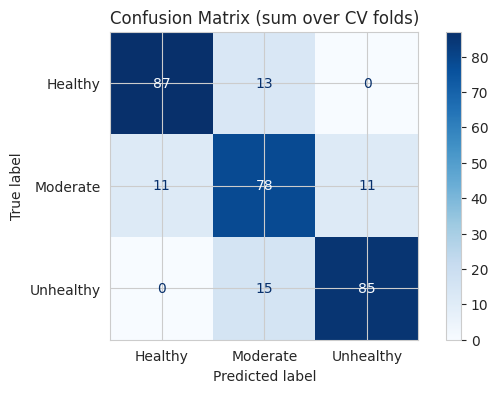

Classification report (pooled across folds):
              precision    recall  f1-score   support

     Healthy       0.89      0.87      0.88       100
    Moderate       0.74      0.78      0.76       100
   Unhealthy       0.89      0.85      0.87       100

    accuracy                           0.83       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.83      0.83       300



In [4]:
def compute_metrics_multiclass(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    out = {'accuracy': acc, 'precision_macro': pr, 'recall_macro': rc, 'f1_macro': f1}
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
            out['auroc_ovr_macro'] = auc
        except Exception:
            out['auroc_ovr_macro'] = float('nan')
    return out

def make_xgb(num_classes):
    return XGBClassifier(
        n_estimators=450,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        random_state=SEED,
        n_jobs=-1,
    )

def cv_evaluate_xgb(X, y, *, use_pca=False, pca_components=8, sample_weight=None, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    num_classes = len(np.unique(y))
    fold_metrics = []
    cms = []
    y_all = []
    pred_all = []

    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        if use_pca:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=pca_components, random_state=SEED)),
                ('xgb', make_xgb(num_classes)),
            ])
            fit_params = {}
            if sample_weight is not None:
                fit_params['xgb__sample_weight'] = sample_weight[tr]
            model.fit(Xtr, ytr, **fit_params)
            ypred = model.predict(Xte)
            yproba = model.predict_proba(Xte)
        else:
            clf = make_xgb(num_classes)
            if sample_weight is None:
                clf.fit(Xtr, ytr)
            else:
                clf.fit(Xtr, ytr, sample_weight=sample_weight[tr])
            ypred = clf.predict(Xte)
            yproba = clf.predict_proba(Xte)

        m = compute_metrics_multiclass(yte, ypred, yproba)
        fold_metrics.append(m)
        cms.append(confusion_matrix(yte, ypred, labels=np.arange(num_classes)))
        y_all.append(yte)
        pred_all.append(ypred)
        print(f'Fold {fold}:', m)

    metrics_df = pd.DataFrame(fold_metrics)
    cm_sum = np.sum(cms, axis=0)
    y_all = np.concatenate(y_all)
    pred_all = np.concatenate(pred_all)
    return metrics_df, cm_sum, y_all, pred_all

metrics_df, cm_sum, y_true_all, y_pred_all = cv_evaluate_xgb(X, y, n_splits=5)
display(metrics_df)
print('\nCV mean±std:')
display(pd.DataFrame({
    'mean': metrics_df.mean(numeric_only=True),
    'std': metrics_df.std(numeric_only=True),
}))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_sum, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (sum over CV folds)')
plt.show()

print('Classification report (pooled across folds):')
print(classification_report(y_true_all, y_pred_all, target_names=class_names, zero_division=0))

## 4) Results Analysis (Discussion Prompts)

In your report/discussion, consider:
- Which classes are most confused in the confusion matrix?
- Which classes have the lowest precision/recall/F1?
- Do engineered ratio features appear important (you can add XGBoost feature importance if desired)?
- Are results stable across folds (std dev) or high variance?

## 5) Experiments

Required-style experiments implemented below:
1) Train-data amount vs performance
2) Simulated imbalance: baseline vs sample-weight vs SMOTE
3) Data augmentation (tabular Gaussian noise) vs none
4) Dimensionality reduction: PCA vs none

Fold 1: {'accuracy': 0.8333333333333334, 'precision_macro': 0.8333333333333334, 'recall_macro': 0.8333333333333334, 'f1_macro': 0.8333333333333334, 'auroc_ovr_macro': 0.84375}
Fold 2: {'accuracy': 0.5833333333333334, 'precision_macro': 0.6666666666666666, 'recall_macro': 0.5833333333333334, 'f1_macro': 0.5925925925925926, 'auroc_ovr_macro': 0.7916666666666666}
Fold 3: {'accuracy': 0.75, 'precision_macro': 0.8571428571428571, 'recall_macro': 0.75, 'f1_macro': 0.709090909090909, 'auroc_ovr_macro': 0.9375}
Fold 4: {'accuracy': 0.5833333333333334, 'precision_macro': 0.6055555555555555, 'recall_macro': 0.5833333333333334, 'f1_macro': 0.5886243386243386, 'auroc_ovr_macro': 0.7083333333333334}
Fold 5: {'accuracy': 0.5833333333333334, 'precision_macro': 0.6666666666666666, 'recall_macro': 0.5833333333333334, 'f1_macro': 0.5555555555555555, 'auroc_ovr_macro': 0.90625}
Fold 1: {'accuracy': 0.875, 'precision_macro': 0.8783068783068783, 'recall_macro': 0.875, 'f1_macro': 0.8745098039215686, 'auroc

,train_fraction,acc_mean,acc_std,f1_mean,f1_std
0,0.2,0.666667,0.117851,0.655839,0.115016
1,0.4,0.833333,0.065881,0.831821,0.065973
2,0.6,0.822222,0.072436,0.823703,0.071519
3,0.8,0.820833,0.023754,0.822502,0.021778
4,1.0,0.833333,0.039087,0.832770,0.038961


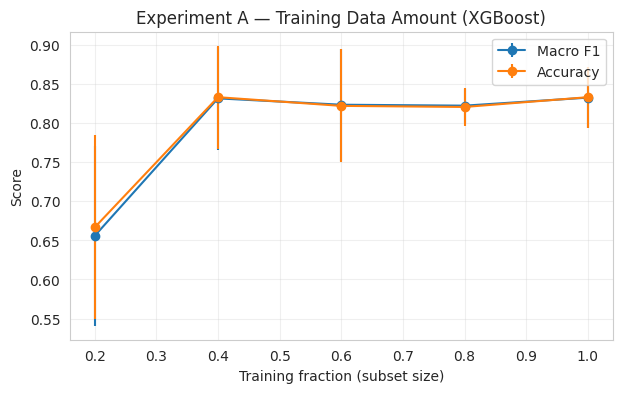

Imbalanced counts: Counter({np.int64(0): 100, np.int64(1): 100, np.int64(2): 30})
Fold 1: {'accuracy': 0.8695652173913043, 'precision_macro': 0.9130116959064326, 'recall_macro': 0.7833333333333333, 'f1_macro': 0.8177933177933178, 'auroc_ovr_macro': 0.9542735042735043}
Fold 2: {'accuracy': 0.8260869565217391, 'precision_macro': 0.8282828282828283, 'recall_macro': 0.8277777777777778, 'f1_macro': 0.8266499582289056, 'auroc_ovr_macro': 0.9442307692307693}
Fold 3: {'accuracy': 0.8695652173913043, 'precision_macro': 0.8653198653198654, 'recall_macro': 0.8611111111111112, 'f1_macro': 0.8617376775271511, 'auroc_ovr_macro': 0.952136752136752}
Fold 4: {'accuracy': 0.8478260869565217, 'precision_macro': 0.9003921568627451, 'recall_macro': 0.8055555555555555, 'f1_macro': 0.8364364364364366, 'auroc_ovr_macro': 0.9321581196581197}
Fold 5: {'accuracy': 0.717391304347826, 'precision_macro': 0.6695906432748537, 'recall_macro': 0.6666666666666666, 'f1_macro': 0.6678132165937044, 'auroc_ovr_macro': 0.902

,method,acc,f1
0,baseline,0.826087,0.802086
1,sample_weight,0.821739,0.801769
2,SMOTE,0.800000,0.777787


Fold 1: {'accuracy': 0.85, 'precision_macro': 0.8588888888888889, 'recall_macro': 0.85, 'f1_macro': 0.8457671957671957, 'auroc_ovr_macro': 0.975}
Fold 2: {'accuracy': 0.7666666666666667, 'precision_macro': 0.8214285714285715, 'recall_macro': 0.7666666666666666, 'f1_macro': 0.7653531777253256, 'auroc_ovr_macro': 0.9366666666666666}
Fold 3: {'accuracy': 0.85, 'precision_macro': 0.8544973544973544, 'recall_macro': 0.85, 'f1_macro': 0.8510911424903722, 'auroc_ovr_macro': 0.9487499999999999}
Fold 4: {'accuracy': 0.8666666666666667, 'precision_macro': 0.8703703703703703, 'recall_macro': 0.8666666666666667, 'f1_macro': 0.8644338118022329, 'auroc_ovr_macro': 0.9741666666666667}
Fold 5: {'accuracy': 0.8333333333333334, 'precision_macro': 0.8527777777777779, 'recall_macro': 0.8333333333333334, 'f1_macro': 0.8372053872053872, 'auroc_ovr_macro': 0.945}


,setting,acc,f1
0,no_aug,0.833333,0.832770
1,gaussian_aug,0.836667,0.835759


Fold 1: {'accuracy': 0.6833333333333333, 'precision_macro': 0.6965350877192983, 'recall_macro': 0.6833333333333332, 'f1_macro': 0.6846153846153845, 'auroc_ovr_macro': 0.88625}
Fold 2: {'accuracy': 0.6833333333333333, 'precision_macro': 0.6950757575757575, 'recall_macro': 0.6833333333333332, 'f1_macro': 0.6851851851851851, 'auroc_ovr_macro': 0.8337500000000001}
Fold 3: {'accuracy': 0.7166666666666667, 'precision_macro': 0.7178932178932179, 'recall_macro': 0.7166666666666667, 'f1_macro': 0.7083439436380612, 'auroc_ovr_macro': 0.8441666666666667}
Fold 4: {'accuracy': 0.7, 'precision_macro': 0.6999999999999998, 'recall_macro': 0.6999999999999998, 'f1_macro': 0.6999999999999998, 'auroc_ovr_macro': 0.8691666666666666}
Fold 5: {'accuracy': 0.6, 'precision_macro': 0.6250724637681159, 'recall_macro': 0.6, 'f1_macro': 0.5964577950043066, 'auroc_ovr_macro': 0.7770833333333332}
Fold 1: {'accuracy': 0.7666666666666667, 'precision_macro': 0.7645502645502645, 'recall_macro': 0.7666666666666666, 'f1_m

,pca_components,acc_mean,f1_mean
0,3,0.676667,0.674920
1,5,0.700000,0.698091
2,8,0.766667,0.766255
3,12,0.773333,0.770590


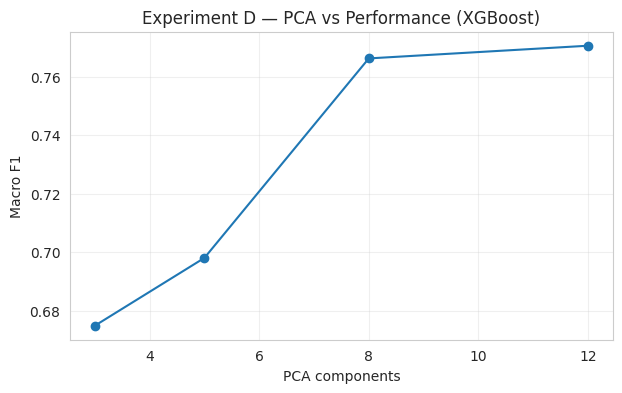

In [5]:
# Experiment helpers
from collections import Counter
from sklearn.utils.class_weight import compute_sample_weight

def stratified_subsample(X, y, frac, seed=SEED):
    frac = float(frac)
    if frac <= 0.0 or frac > 1.0:
        raise ValueError('frac must be in the range (0, 1].')
    if frac == 1.0:
        # Full dataset requested; no split needed.
        return X.copy(), y.copy()

    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=seed)
    (idx, _), = sss.split(X, y)
    return X[idx], y[idx]

def simulate_imbalance(X, y, keep_fraction_for_last_class=0.30, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    target = classes[-1]  # downsample one class
    idx_target = np.where(y == target)[0]
    idx_other = np.where(y != target)[0]
    keep_n = max(10, int(len(idx_target) * keep_fraction_for_last_class))
    keep_idx = rng.choice(idx_target, size=keep_n, replace=False)
    idx = np.concatenate([idx_other, keep_idx])
    rng.shuffle(idx)
    return X[idx], y[idx]

def augment_gaussian(Xtr, ytr, copies=2, noise_std=0.015, seed=SEED):
    rng = np.random.default_rng(seed)
    feat_std = Xtr.std(axis=0, keepdims=True)
    feat_std = np.where(feat_std == 0, 1.0, feat_std)
    Xs = [Xtr]
    ys = [ytr]
    for k in range(copies):
        noise = rng.normal(0.0, noise_std, size=Xtr.shape) * feat_std
        Xs.append(Xtr + noise)
        ys.append(ytr)
    return np.vstack(Xs), np.concatenate(ys)

def cv_evaluate_xgb_with_augmentation(X, y, copies=2, noise_std=0.015, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    num_classes = len(np.unique(y))
    fold_metrics = []
    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]
        Xaug, yaug = augment_gaussian(Xtr, ytr, copies=copies, noise_std=noise_std, seed=SEED+fold)
        clf = make_xgb(num_classes)
        clf.fit(Xaug, yaug)
        ypred = clf.predict(Xte)
        yproba = clf.predict_proba(Xte)
        fold_metrics.append(compute_metrics_multiclass(yte, ypred, yproba))
    return pd.DataFrame(fold_metrics)

# A) Effect of training data amount
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    Xs, ys = stratified_subsample(X, y, frac)
    mdf, _, _, _ = cv_evaluate_xgb(Xs, ys, n_splits=5)
    rows.append({
        'train_fraction': frac,
        'acc_mean': float(mdf['accuracy'].mean()),
        'acc_std': float(mdf['accuracy'].std()),
        'f1_mean': float(mdf['f1_macro'].mean()),
        'f1_std': float(mdf['f1_macro'].std()),
    })
expA = pd.DataFrame(rows)
display(expA)
plt.errorbar(expA['train_fraction'], expA['f1_mean'], yerr=expA['f1_std'], marker='o', label='Macro F1')
plt.errorbar(expA['train_fraction'], expA['acc_mean'], yerr=expA['acc_std'], marker='o', label='Accuracy')
plt.xlabel('Training fraction (subset size)'); plt.ylabel('Score')
plt.title('Experiment A — Training Data Amount (XGBoost)')
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

# B) Simulated imbalance: baseline vs weighting vs SMOTE
X_imb, y_imb = simulate_imbalance(X, y, keep_fraction_for_last_class=0.30)
print('Imbalanced counts:', Counter(y_imb))
mdf_base, _, _, _ = cv_evaluate_xgb(X_imb, y_imb, n_splits=5)
sw = compute_sample_weight(class_weight='balanced', y=y_imb)
mdf_w, _, _, _ = cv_evaluate_xgb(X_imb, y_imb, sample_weight=sw, n_splits=5)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
def cv_evaluate_smote_xgb(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    num_classes = len(np.unique(y))
    fold_metrics = []
    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]
        model = ImbPipeline([('smote', SMOTE(random_state=SEED)), ('xgb', make_xgb(num_classes))])
        model.fit(Xtr, ytr)
        ypred = model.predict(Xte)
        yproba = model.predict_proba(Xte)
        fold_metrics.append(compute_metrics_multiclass(yte, ypred, yproba))
    return pd.DataFrame(fold_metrics)
mdf_smote = cv_evaluate_smote_xgb(X_imb, y_imb, n_splits=5)
expB = pd.DataFrame([
    {'method':'baseline', 'acc': mdf_base['accuracy'].mean(), 'f1': mdf_base['f1_macro'].mean()},
    {'method':'sample_weight', 'acc': mdf_w['accuracy'].mean(), 'f1': mdf_w['f1_macro'].mean()},
    {'method':'SMOTE', 'acc': mdf_smote['accuracy'].mean(), 'f1': mdf_smote['f1_macro'].mean()},
])
display(expB)

# C) Data augmentation: Gaussian noise
mdf_no_aug, _, _, _ = cv_evaluate_xgb(X, y, n_splits=5)
mdf_aug = cv_evaluate_xgb_with_augmentation(X, y, copies=2, noise_std=0.015, n_splits=5)
expC = pd.DataFrame([
    {'setting':'no_aug', 'acc': mdf_no_aug['accuracy'].mean(), 'f1': mdf_no_aug['f1_macro'].mean()},
    {'setting':'gaussian_aug', 'acc': mdf_aug['accuracy'].mean(), 'f1': mdf_aug['f1_macro'].mean()},
])
display(expC)

# D) Dimensionality reduction: PCA sweep
pca_components_list = [3, 5, 8, 12]
rows = []
for k in pca_components_list:
    mdf_pca, _, _, _ = cv_evaluate_xgb(X, y, use_pca=True, pca_components=k, n_splits=5)
    rows.append({'pca_components': k, 'acc_mean': float(mdf_pca['accuracy'].mean()), 'f1_mean': float(mdf_pca['f1_macro'].mean())})
expD = pd.DataFrame(rows)
display(expD)
plt.plot(expD['pca_components'], expD['f1_mean'], marker='o')
plt.xlabel('PCA components'); plt.ylabel('Macro F1')
plt.title('Experiment D — PCA vs Performance (XGBoost)')
plt.grid(True, alpha=0.3); plt.show()